In [3]:
import torch
import numpy as np
import pandas as pd
from pathlib import Path
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader
from traincae import DEFAULT_PARAMS, SlidingWindowDataset
from loadData import RawDataset, preprocess_hydraulic_data, preprocess_hydraulic_synthetic_dataset, obtain_ground_truth
from findAnomalies import *
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [15]:
### Loading the model and the dataset
unit = "VG6"
unit_model = "VG5"
mode ="turbine"

# Your existing paths
base_path = Path("./models")
dataset_path = Path("../dataset")
model_path = base_path / f"models_{unit_model}_{mode}/best_cae_model_{unit_model}_{mode}.pth"

# Load scaler_control.pkl from the data folder
with open(f'data/scaler_{unit_model}_{mode}.pkl', 'rb') as file:
    scaler = joblib.load(file)

# Load model and parameters
checkpoint = torch.load(model_path, map_location=device)
DEFAULT_PARAMS = checkpoint['params']

operating_conditions_set = {
    "dyn_only_on": False, "turbine_mode": True, "equilibrium_turbine_mode": True, "short_circuit_mode": False
}

# LOAD PARAMETERS
SYNTHETIC_PARAMS = {
    'unit': unit,
    'test_set': '02',
    'anomaly_type': 'a',
    'set_type':'test_s02'
}

# Load parameters directly from checkpoint
DEFAULT_PARAMS = checkpoint['params']  # This contains all the parameters used during training

training_df = pd.read_parquet(f'data/training_{unit}_{mode}.parquet')


# Create dataset for evaluation
train_dataset = SlidingWindowDataset(
    training_df,
    window=DEFAULT_PARAMS['window_size'],
    device=device
)

# Create dataloader
train_loader = DataLoader(
    train_dataset,
    batch_size=DEFAULT_PARAMS['batch_size'],
    shuffle=False  # Important: keep order for anomaly detection
)

scaler, threshold_df, model = load_model(unit = unit_model, mode = mode)

/tmp/ipykernel_43667/860553150.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)
/home/matthieu/Documents/ML pred

In [16]:
reconstructed_df = reconstruct_signal_from_windows(train_loader,training_df, model, device)

Reconstructing signals:   0%|          | 0/1309 [00:00<?, ?it/s]

Reconstructing signals: 100%|██████████| 1309/1309 [01:02<00:00, 20.84it/s]


In [17]:
target_columns = ['water_circ_flow', 'tot_reactivepower', 'water_circ_hot_05_tmp', 'air_circ_hot_02_tmp',
                  'stat_coil_ph03_02_tmp', 'stat_magn_07_tmp']

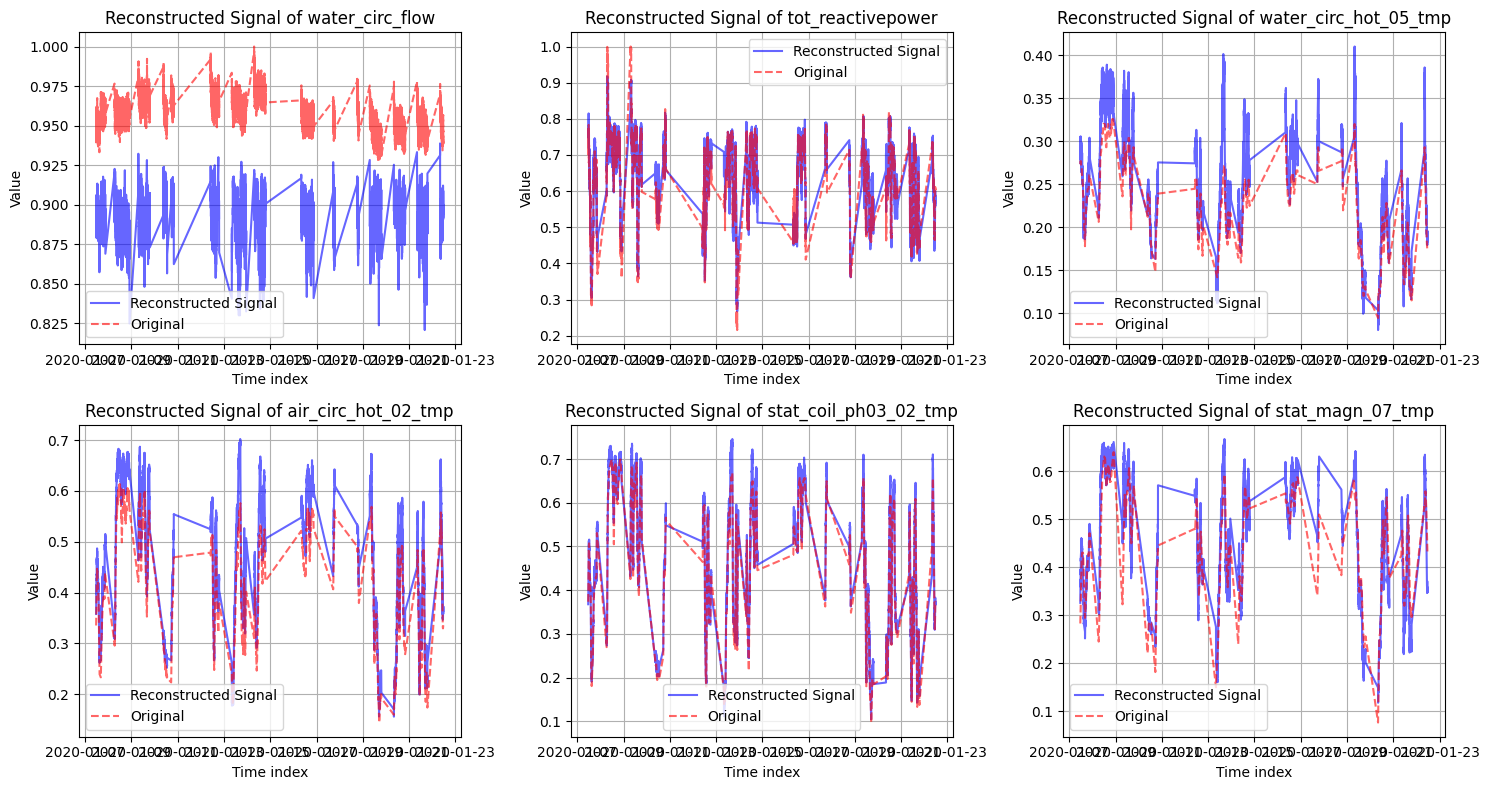

In [18]:
fig, axs = plt.subplots(2, 3, figsize=(15, 8))

for i, column in enumerate(target_columns):
    row = i // 3
    col = i % 3

    # First subplot
    axs[row, col].plot(reconstructed_df[column][2000:16000], label='Reconstructed Signal', color='b', alpha=0.6)
    axs[row, col].plot(training_df[column][2000:16000], label="Original", color='r', linestyle='--', alpha=0.6)
    axs[row, col].set_xlabel('Time index')
    axs[row, col].set_ylabel('Value')
    axs[row, col].set_title(f'Reconstructed Signal of {column}')
    axs[row, col].grid()
    axs[row, col].legend()

# Hide any unused subplots
for j in range(len(target_columns), 6):
    row = j // 3
    col = j % 3
    fig.delaxes(axs[row, col])

plt.tight_layout()
plt.savefig(f"../images/reconstruction_VG5_Model_{unit}_{mode}.pdf")
plt.show()

# Finding the anomalies on the synthetic dataset

In [19]:
# LOAD PARAMETERS
SYNTHETIC_PARAMS = {
    'unit': unit,
    'test_set': '02',
    'anomaly_type': 'a',
    'set_type':'test_s02'
}

dataset_path = Path("../dataset")

rds_u5_buffer = RawDataset(dataset_path, "VG5", load_synthetic=False, load_training=False)

if mode=='turbine':
    turbine_or_pump=True
else: turbine_or_pump=False

test_syn_df = preprocess_hydraulic_synthetic_dataset(rds_train=rds_u5_buffer,
                                                     training_df=training_df, 
                                                     unit=SYNTHETIC_PARAMS["unit"],
                                                     number = SYNTHETIC_PARAMS["test_set"],
                                                     Type = SYNTHETIC_PARAMS["anomaly_type"],
                                                     scaler=scaler,
                                                     turbine_or_pump=turbine_or_pump)


# Getting the ground truth labels
ground_truth,_ = obtain_ground_truth(dataset_path, 
                                   unit = SYNTHETIC_PARAMS["unit"],
                                   test_set=SYNTHETIC_PARAMS["test_set"],
                                   anomaly_type=SYNTHETIC_PARAMS["anomaly_type"])
# Only keeping the correct labels
ground_truth = ground_truth[test_syn_df.index]

# Create dataset for evaluation
test_dataset = SlidingWindowDataset(
    test_syn_df,
    window=DEFAULT_PARAMS['window_size'],
    device=device
)

# Create dataloader
test_loader = DataLoader(
    test_dataset,
    batch_size=DEFAULT_PARAMS['batch_size'],
    shuffle=False  # Important: keep order for anomaly detection
)


In [20]:
reconstructed_test_df = reconstruct_signal_from_windows(test_loader, test_syn_df, model, device)

Reconstructing signals:   0%|          | 0/217 [00:00<?, ?it/s]

Reconstructing signals: 100%|██████████| 217/217 [00:10<00:00, 19.77it/s]


In [21]:
error_test = compute_error(test_syn_df,reconstructed_test_df)

faulty_df = (error_test>threshold_df)
faulty_df = filter_faulty_df(faulty_df, 200)

faulty_signals_df = get_faulty_signals(faulty_df)

#ind_fault = get_indexes_fault(faulty_df, column="stat_coil_ph03_05_tmp")

Processing columns: 100%|██████████| 84/84 [01:19<00:00,  1.06it/s]


In [22]:
target_columns = faulty_signals_df.head(10).index

print(target_columns)

Index(['water_circ_flow', 'pump_rotspeed', 'stat_magn_08_tmp',
       'stat_coil_ph01_05_tmp', 'stat_magn_11_tmp', 'air_circ_cold_05_tmp',
       'air_circ_hot_01_tmp', 'air_circ_cold_01_tmp', 'stat_magn_07_tmp',
       'stat_coil_ph01_06_tmp'],
      dtype='object')


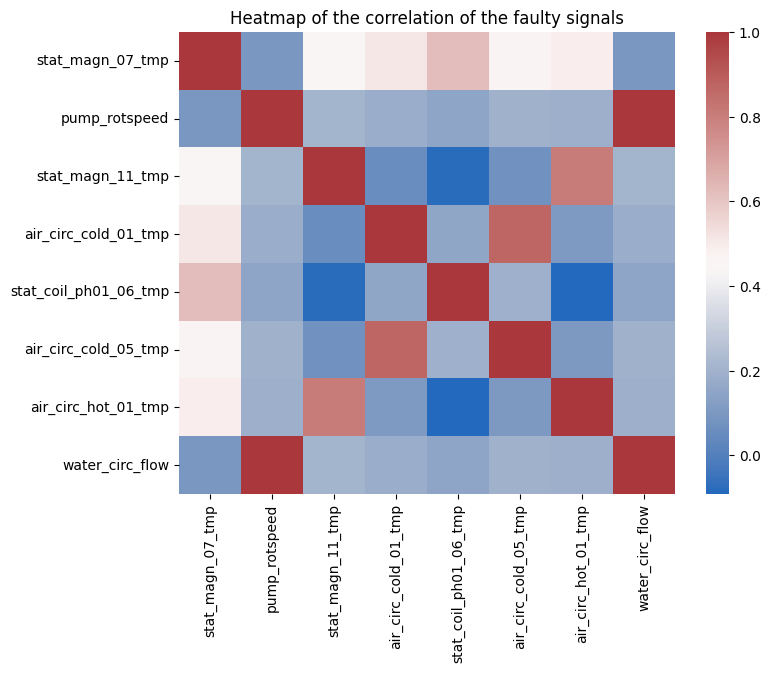

In [35]:
corr_faulty_df = correlation_faulty_signals(faulty_df, target_columns, 
                                            f"../images/corr_map_transfer_VG5_model_syn_02_a_{unit}_{mode}.pdf"
                                            )

In [24]:
unique_correlated_names = find_unique_correlations(corr_faulty_df, 0.6)
print(unique_correlated_names)

['stat_magn_07_tmp', 'pump_rotspeed', 'stat_magn_11_tmp', 'air_circ_cold_01_tmp', 'stat_coil_ph01_06_tmp', 'air_circ_cold_05_tmp', 'air_circ_hot_01_tmp', 'water_circ_flow']


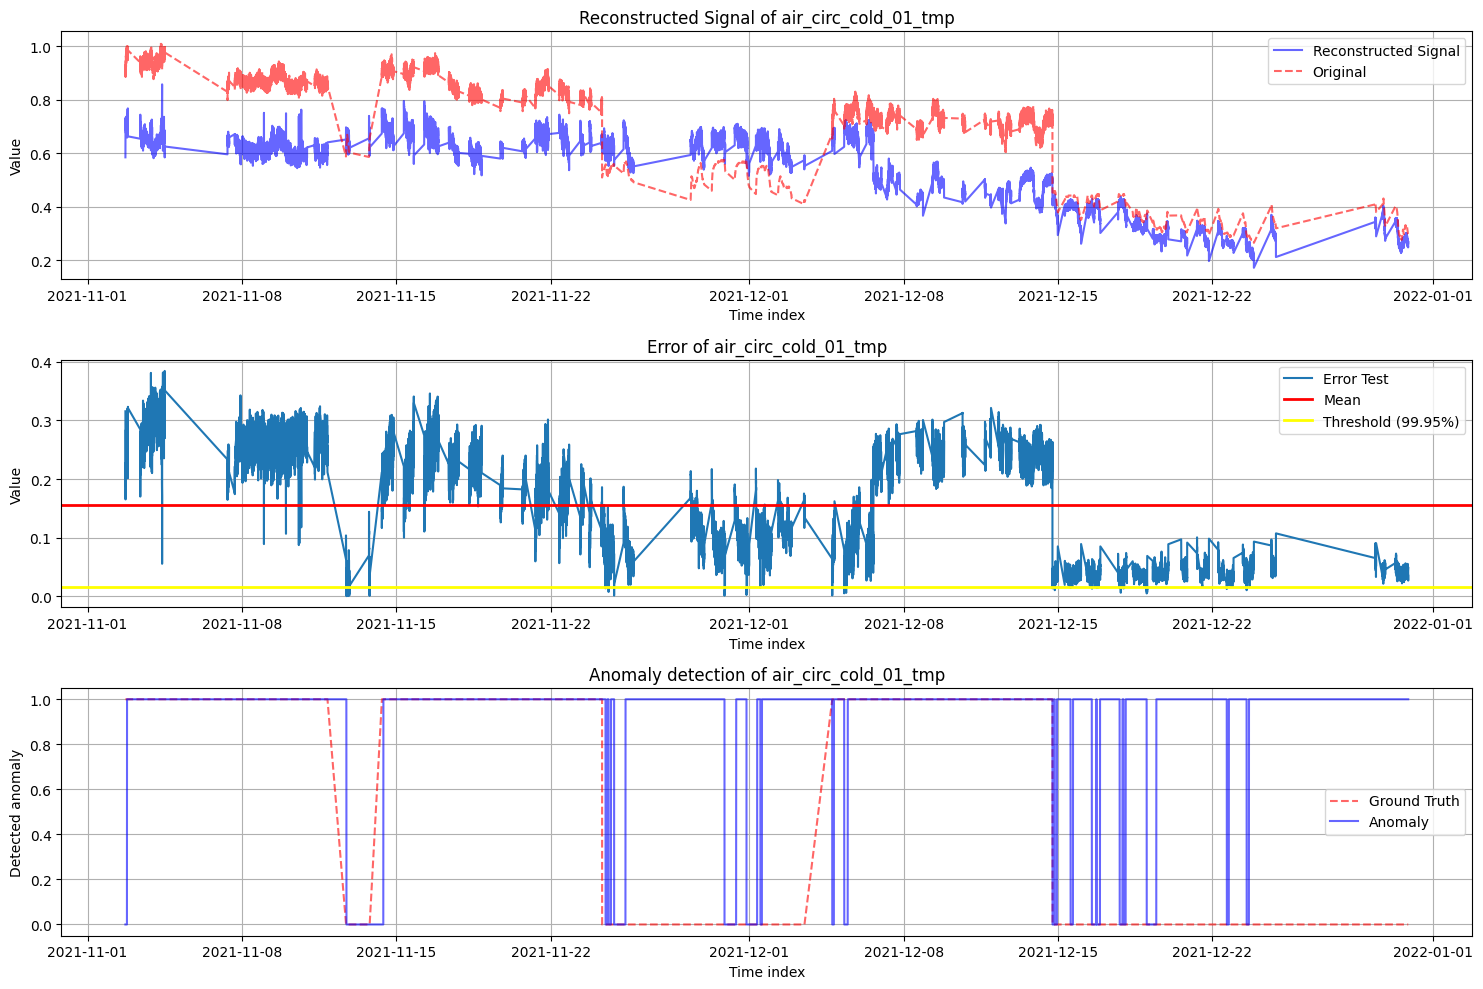

In [36]:
target_columns = unique_correlated_names
i=3 # Change the value to change the column

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 10))

# First subplot
ax1.plot(reconstructed_test_df[target_columns[i]], label='Reconstructed Signal', color='b', alpha=0.6)
ax1.plot(test_syn_df[target_columns[i]], label="Original", color='r', linestyle='--', alpha=0.6)
ax1.set_xlabel('Time index')
ax1.set_ylabel('Value')
ax1.set_title(f'Reconstructed Signal of {target_columns[i]}')
ax1.grid()
ax1.legend()

# Second subplot
ax2.plot(error_test[target_columns[i]], label="Error Test")
ax2.axhline(np.mean(error_test[target_columns[i]]), color='red', linewidth=2, label="Mean")
threshold = threshold_df[target_columns[i]]
ax2.axhline(threshold, color='yellow', linewidth=2, label="Threshold (99.95%)")
ax2.set_xlabel('Time index')
ax2.set_ylabel('Value')
ax2.set_title(f'Error of {target_columns[i]}')
ax2.grid()
ax2.legend()

ax3.plot(ground_truth, label = "Ground Truth", color='r', linestyle='--', alpha=0.6)
ax3.plot(faulty_df[target_columns[i]], label="Anomaly", color='b', alpha=0.6)
ax3.set_xlabel('Time index')
ax3.set_ylabel('Detected anomaly')
ax3.set_title(f'Anomaly detection of {target_columns[i]}')
ax3.grid()
ax3.legend()

plt.tight_layout()
plt.savefig(f'../images/error_derivation_transfer_VG5_model_{unit}_{mode}')
plt.show()

In [28]:
anomaly_labels = faulty_df[target_columns[0]]

for column in target_columns:
    anomaly_labels &= faulty_df[column]

In [29]:
# Compute ROC curve and find optimal threshold
fpr, tpr, thresholds = roc_curve(ground_truth[:-1], anomaly_labels)
roc_auc = auc(fpr, tpr)

# Compute confusion matrix
cm = confusion_matrix(ground_truth[:-1], anomaly_labels)

# Get classification report
report = classification_report(ground_truth[:-1], anomaly_labels)

results = {
        'roc_curve': (fpr, tpr, roc_auc),
        'confusion_matrix': cm,
        'classification_report': report
    }

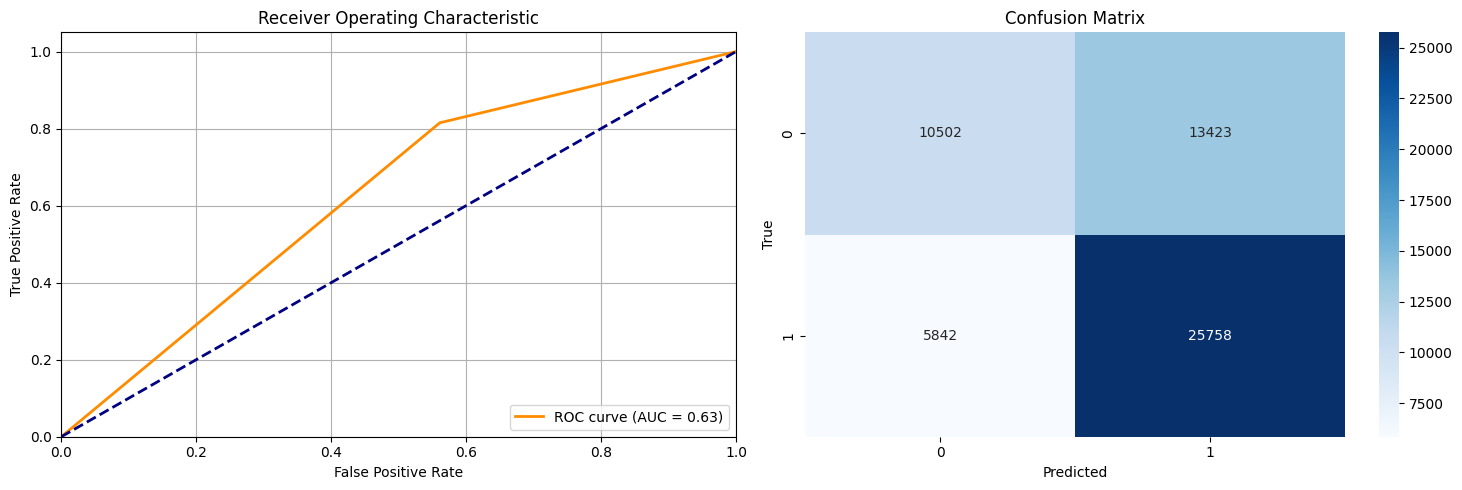


Classification Report:
              precision    recall  f1-score   support

         0.0       0.64      0.44      0.52     23925
         1.0       0.66      0.82      0.73     31600

    accuracy                           0.65     55525
   macro avg       0.65      0.63      0.62     55525
weighted avg       0.65      0.65      0.64     55525



In [30]:
def plot_evaluation_results(results, unit=unit, mode=mode):
    """
    Plot evaluation results including ROC curves and confusion matrix.
    
    Args:
        results: dictionary containing evaluation results
        target_columns: list of column names with injected anomalies
    """
    # Create figure with subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot ROC curve
    fpr, tpr, roc_auc = results['roc_curve']
    ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax1.set_xlim([0.0, 1.0])
    ax1.set_ylim([0.0, 1.05])
    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('True Positive Rate')
    ax1.set_title('Receiver Operating Characteristic')
    ax1.legend(loc="lower right")
    ax1.grid(True)
    
    # Plot confusion matrix
    sns.heatmap(results['confusion_matrix'], annot=True, fmt='d', cmap='Blues', ax=ax2)
    ax2.set_title('Confusion Matrix')
    ax2.set_xlabel('Predicted')
    ax2.set_ylabel('True')
    
    plt.tight_layout()
    plt.savefig(f"../images/score_syn_transfer_VG5_model_{unit}_{mode}.pdf")
    plt.show()

    # Print classification report
    print("\nClassification Report:")
    print(results['classification_report'])
    

plot_evaluation_results(results)